<a href="https://colab.research.google.com/github/athsnd1/Disease-Predictor-ML-Suite/blob/main/Predictive_Modelling_Of_Healthcare_Expenditure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive') #no idea why i mounted drive here lol

Mounted at /content/drive


In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/insurance.csv')

In [3]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


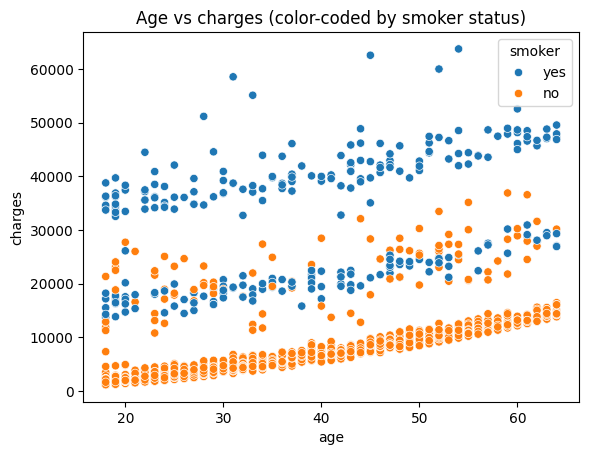

In [9]:
#visualize relationships:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df,x='age',y='charges',hue='smoker')
plt.title('Age vs charges (color-coded by smoker status)')
plt.show()

In [11]:
#check which features have the strongest mathematical connection to charges:
print(df.corr(numeric_only=True))

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


In [14]:
#convert categorical variables to numeric
df_encoded = pd.get_dummies(df,columns=['sex','smoker','region'],drop_first=True)

df_encoded = df_encoded.astype(int)

print(df_encoded.head())

   age  bmi  children  charges  sex_male  smoker_yes  region_northwest  \
0   19   27         0    16884         0           1                 0   
1   18   33         1     1725         1           0                 0   
2   28   33         3     4449         1           0                 0   
3   33   22         0    21984         1           0                 1   
4   32   28         0     3866         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [15]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the numerical features (age, bmi, children)
# We only scale the numeric columns, not the binary ones (0s and 1s)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error (RMSE): $5,793.66
R-squared Score: 0.7838


In [17]:
#DataFrame to view feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

            Feature  Coefficient
4        smoker_yes  9560.318359
0               age  3616.670487
1               bmi  2034.266569
2          children   519.699072
3          sex_male    -8.628539
5  region_northwest  -155.379866
6  region_southeast  -294.470642
7  region_southwest  -353.344025
